In [1]:
%load_ext autoreload
%autoreload 2

Buffer of size $10^4$ fits into 5 Gb RAM.

Larger sizes ($10^5$ and $10^6$ are common) can be used. It can improve the learning, but $10^4$ is quiet enough. $10^2$ will probably fail learning.

In [2]:
import gymnasium as gym
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import ale_py
from functools import partial
import dqn
import losses
import metrics
from train import train, make_env
import pickle
import os

gym.register_envs(ale_py)
%matplotlib inline

In [ ]:
config = {
    "seed": 42,
    "timesteps_per_epoch": 1,
    "batch_size": 32,
    "total_steps": 100000,
    "decay_steps": 50000,
    "lr": 2.5e-4   ,
    "init_epsilon": 1,
    "final_epsilon": 0.1,
    "loss_freq": 50,
    "refresh_target_network_freq": 5000,
    "eval_freq": 5000,
    "max_grad_norm": 50,
    "n_lives": 5,
    "device": "mps",
    "stop_after_n_steps": 100000,
    "td_loss_func" : partial(
        losses.compute_td_ce_loss, min_value=-10, max_value=10, num_bins=51, sigma=0.75, device="mps", method=losses.HLGaussLoss
    ),
    "model_type" : partial(dqn.ClassifierDQNAgent, min_value=-10, max_value=10, num_bins=51, hidden_size=256) 
}

In [17]:
results = train(config)

Total parameters: 879228
10000


  0%|          | 0/100001 [00:00<?, ?it/s]


TypeError: compute_td_ce_loss() missing 1 required positional argument: 'method'

In [13]:
os.makedirs("results", exist_ok=True)
with open(f'results/ce_gauss_seed{config["seed"]}.pkl', 'wb') as file:
    pickle.dump(results, file)

Final scoring is done on a whole episode with all 5 lives.

In [15]:
final_score = metrics.evaluate(
  make_env(clip_rewards=False, seed=9),
    results["agent"], n_games=500, greedy=True, t_max=10 * 1000
) * config["n_lives"]
print('final score:', final_score)


final score: 20.049999999999997


buffer size = 100000, epsilon = 0.10000


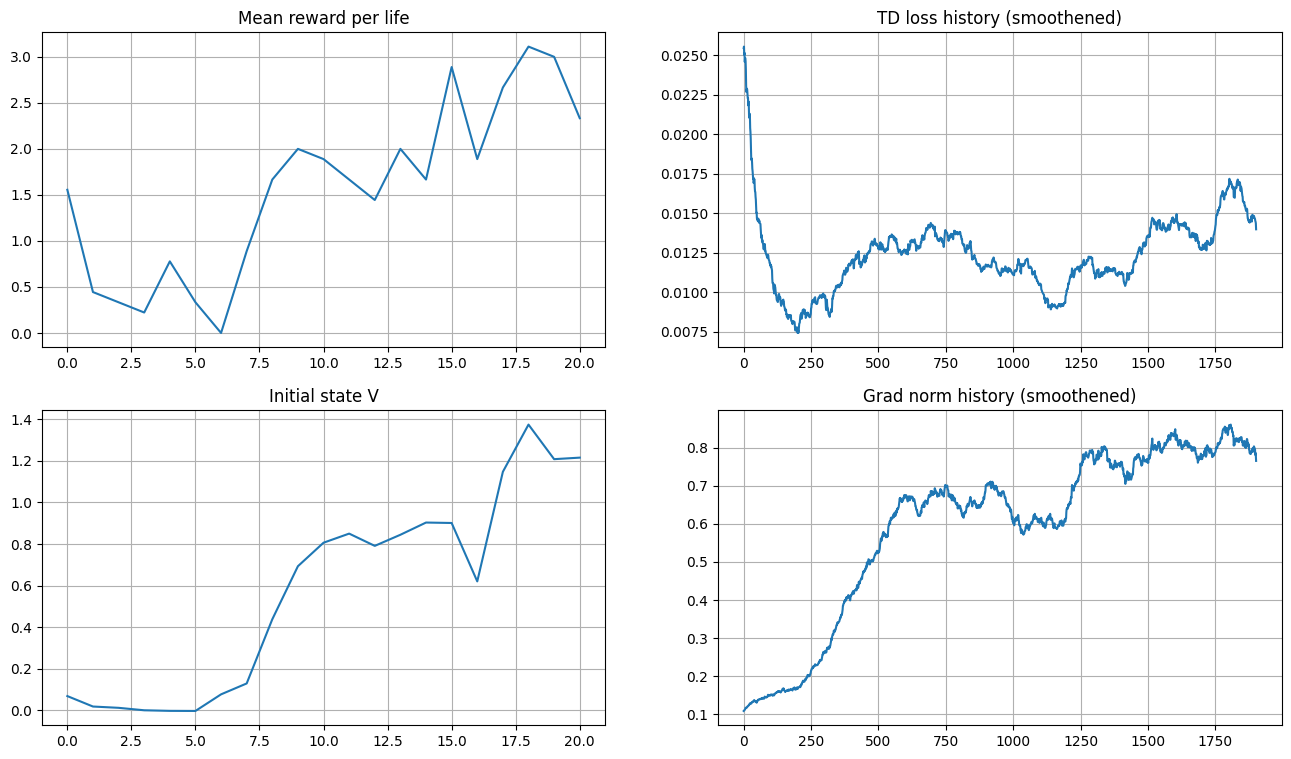

100%|██████████| 100001/100001 [10:39<00:00, 156.27it/s]


final score: 16.666666666666668


In [8]:
config = {
    "seed": 42,
    "timesteps_per_epoch": 1,
    "batch_size": 32,
    "total_steps": 100000,
    "decay_steps": 50000,
    "lr": 6.25e-5,
    "init_epsilon": 1,
    "final_epsilon": 0.1,
    "loss_freq": 50,
    "refresh_target_network_freq": 5000,
    "eval_freq": 5000,
    "max_grad_norm": 50,
    "n_lives": 5,
    "device": "mps",
    "stop_after_n_steps": 100000,
    "td_loss_func" : losses.compute_td_loss,
    "model_type" : dqn.DQNAgent
}
results = train(config)
os.makedirs("results", exist_ok=True)
with open(f'results/mse_seed{config["seed"]}.pkl', 'wb') as file:
    pickle.dump(results, file)

final_score = metrics.evaluate(
  make_env(clip_rewards=False, seed=9),
    results["agent"], n_games=30, greedy=True, t_max=10 * 1000
) * config["n_lives"]
print('final score:', final_score)


# Record a video

In [71]:
# record sessions
from gymnasium.wrappers import RecordVideo

with RecordVideo(env=make_env(), video_folder='./videos',
                 episode_trigger = lambda episode_number: True) as env_monitor:
    sessions = [evaluate(env_monitor, agent, n_games=n_lives,
                         greedy=True) for _ in range(10)]
env.close()

/Users/kdzhr/RL/HW1/.venv/lib/python3.9/site-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /Users/kdzhr/RL/HW1/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-0.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-0.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-1.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-1.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-1.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-2.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-2.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-2.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-3.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-3.mp4



...

MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-45.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-46.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-46.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-46.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-47.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-47.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-47.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-48.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-48.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-48.mp4
MoviePy - Building video /Users/kdzhr/RL/HW1/videos/rl-video-episode-49.mp4.
MoviePy - Writing video /Users/kdzhr/RL/HW1/videos/rl-video-episode-49.mp4



MoviePy - Done !
MoviePy - video ready /Users/kdzhr/RL/HW1/videos/rl-video-episode-49.mp4


In [82]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[7]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

# Let's have a closer look at this (up to 1 point)

Make a more complete record of an episode.

In [76]:
eval_env = make_env(clip_rewards=False)
record = utils.play_and_log_episode(eval_env, agent)
print('total reward for life:', np.sum(record['rewards']))
for key in record:
    print(key)

total reward for life: 6.0
states
v_mc
v_agent
q_spreads
td_errors
rewards
episode_finished


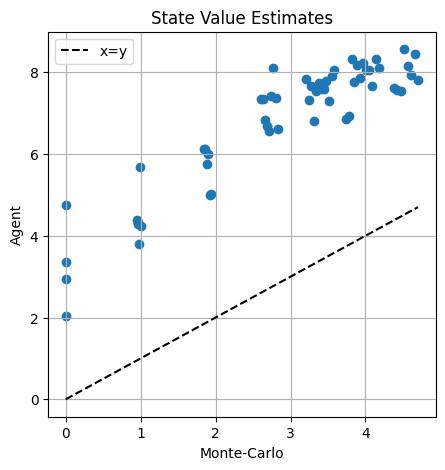

In [77]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(record['v_mc'], record['v_agent'])
ax.plot(sorted(record['v_mc']), sorted(record['v_mc']),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('State Value Estimates')
ax.set_xlabel('Monte-Carlo')
ax.set_ylabel('Agent')

plt.show()

$\hat V_{Monte-Carlo}(s_t) = \sum_{\tau=0}^{episode~end} \gamma^{\tau-t}r_t$

Is there a big bias? It's ok, anyway it works.

**1.** Plot several (say 3) states with high and low spreads of Q estimate by actions i.e.
$$\max_a \hat Q(s,a) - \min_a \hat Q(s,a)\$$
Please take those states from different episodes to make sure that the states are really different.

What should high and low spread mean at least in the world of perfect Q-fucntions?

Comment the states you like most.

**2.** Plot several (say 3) states with high td-error and several states with high values of
$$| \hat V_{Monte-Carlo}(s) - \hat V_{agent}(s)|,$$
$$\hat V_{agent}(s) = \max_a \hat Q(s,a).$$

Please take those states from different episodes to make sure that the states are really different. From what part (i.e. beginning, middle, end) of an episode did these states come from?

Comment the states you like most.

## Task 1

In [ ]:
from utils import play_and_log_episode, img_by_obs

records = []
NUM_EPISODES = 3

for i in range(NUM_EPISODES):
    eval_env = make_env(clip_rewards=False)
    records.append(play_and_log_episode(eval_env, agent))
    print(f'total reward for life on episode {i}:', np.sum(records[-1]['rewards']))


total reward for life on episode 0: 6.0
total reward for life on episode 1: 5.0
total reward for life on episode 2: 10.0


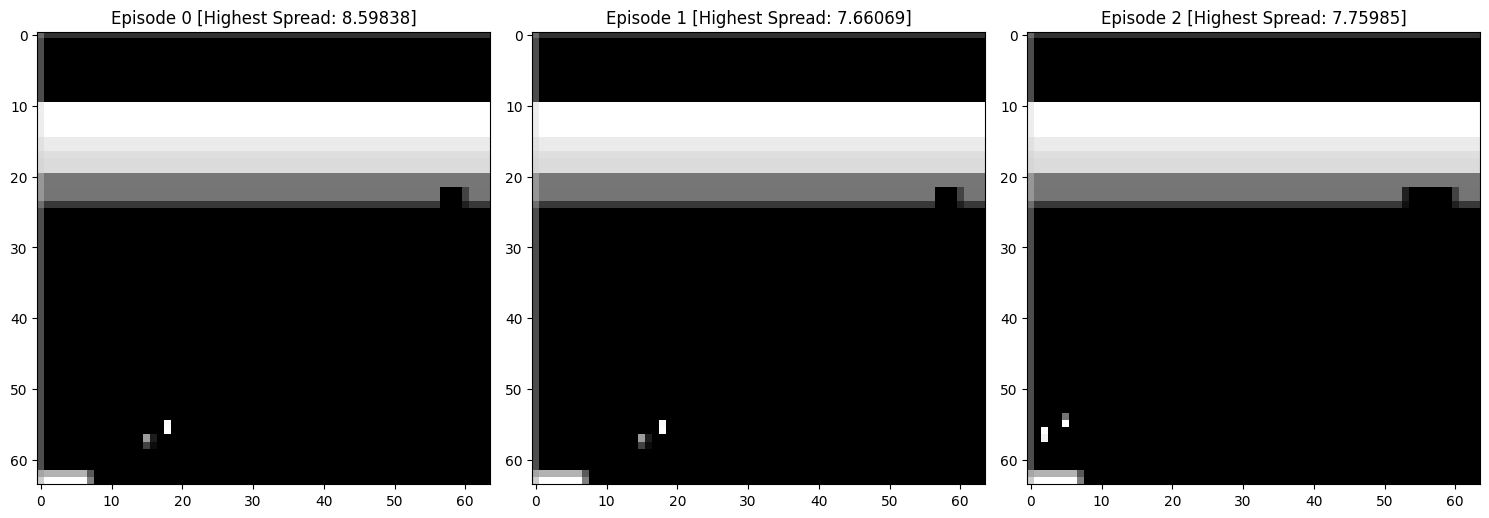

In [105]:
_, axs = plt.subplots(1, NUM_EPISODES, figsize=[NUM_EPISODES * 5, 15])

for i, ax in enumerate(axs):
    ind_max = records[i]['q_spreads'].argmax()
    spread = records[i]['q_spreads'][ind_max]
    img = img_by_obs(records[i]['states'][ind_max][0:1], state_shape)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Episode {i} [Highest Spread: {spread:.5f}]")

plt.tight_layout()
plt.show()

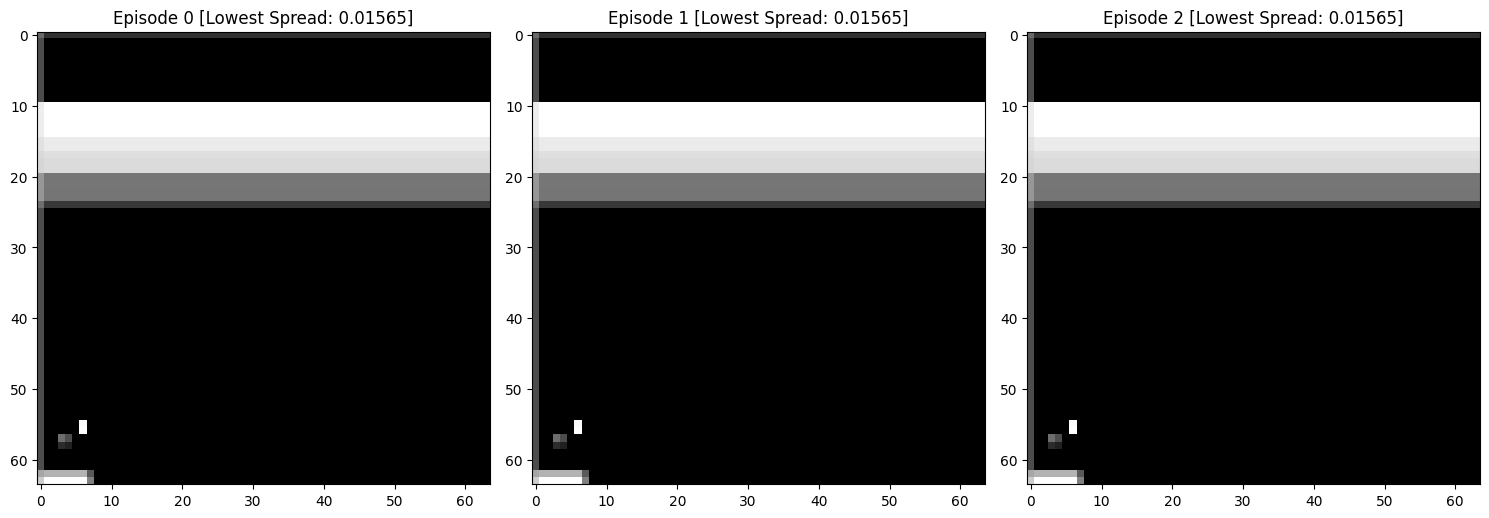

In [106]:
_, axs = plt.subplots(1, NUM_EPISODES, figsize=[NUM_EPISODES * 5, 15])

for i, ax in enumerate(axs):
    ind_min = records[i]['q_spreads'].argmin()
    spread = records[i]['q_spreads'][ind_min]
    img = img_by_obs(records[i]['states'][ind_min][0:1], state_shape)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Episode {i} [Lowest Spread: {spread:.5f}]")

plt.tight_layout()
plt.show()

The high spread of Q estimates across actions signals the presence of a high impact action, be it positive or negative. In the shown images we see the high impact action: adjust the platform so the ball bounces off it. Otherwise, when the spread is low you can't change much: the ball touches the platform regardless of the action taken.

## Task 2

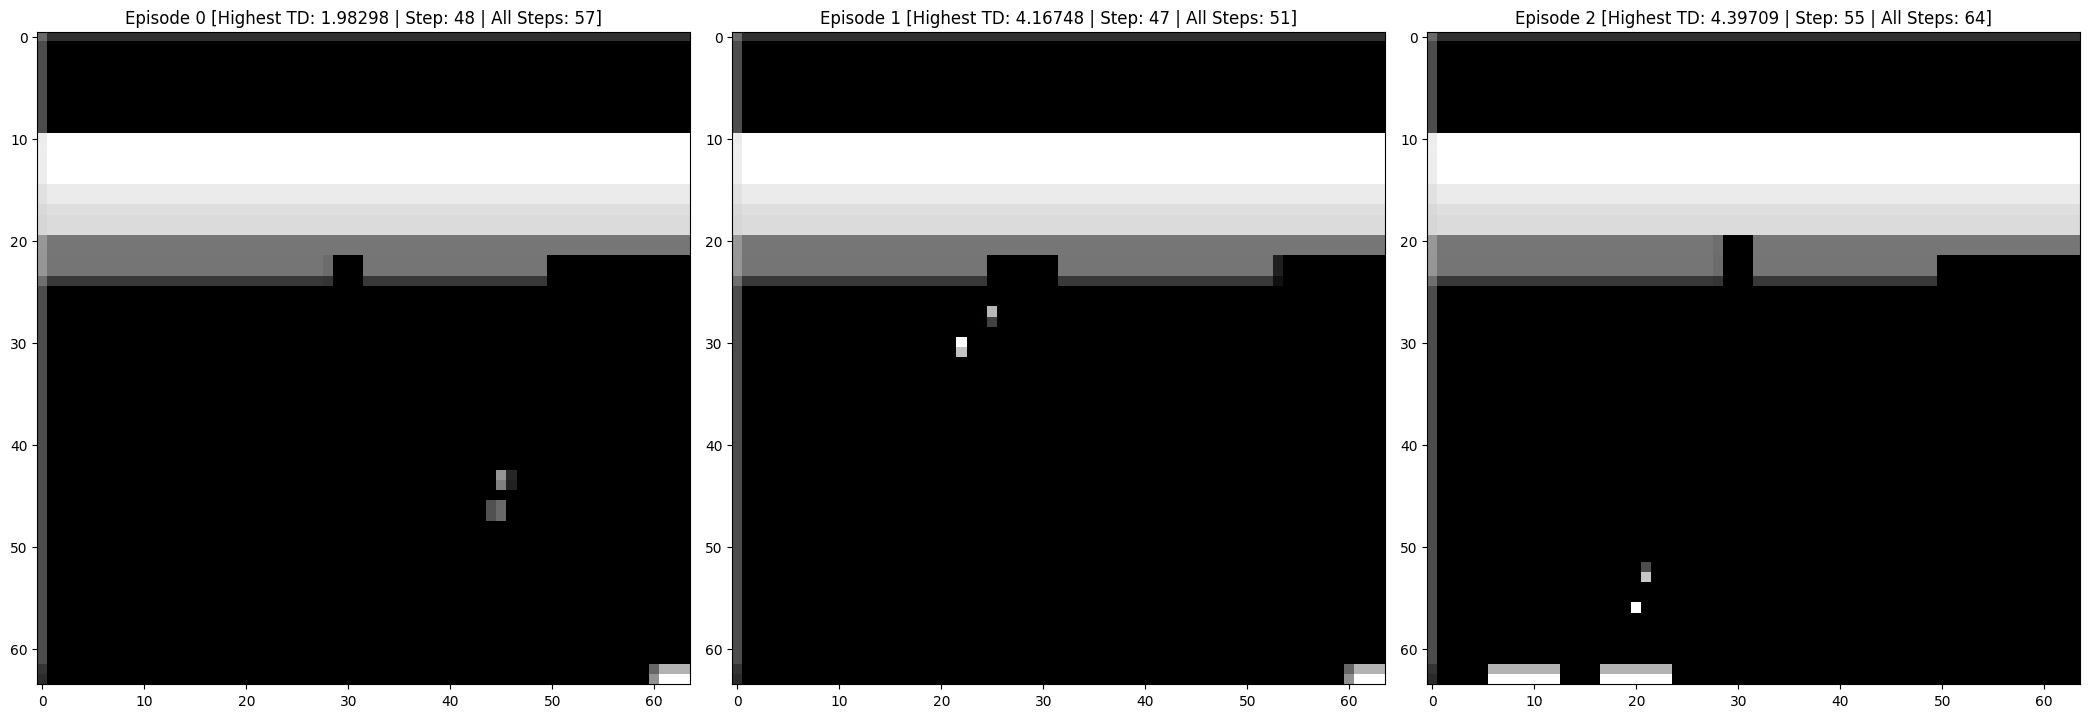

In [114]:
_, axs = plt.subplots(1, NUM_EPISODES, figsize=[NUM_EPISODES * 7, 15])

for i, ax in enumerate(axs):
    ind_max = records[i]['td_errors'].argmax()
    td_error = records[i]['td_errors'][ind_max]
    img = img_by_obs(records[i]['states'][ind_max][0:1], state_shape)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Episode {i} [Highest TD: {td_error:.5f} | Step: {ind_max} | All Steps: {records[i]['td_errors'].shape[0]}]")

plt.tight_layout()
plt.show()

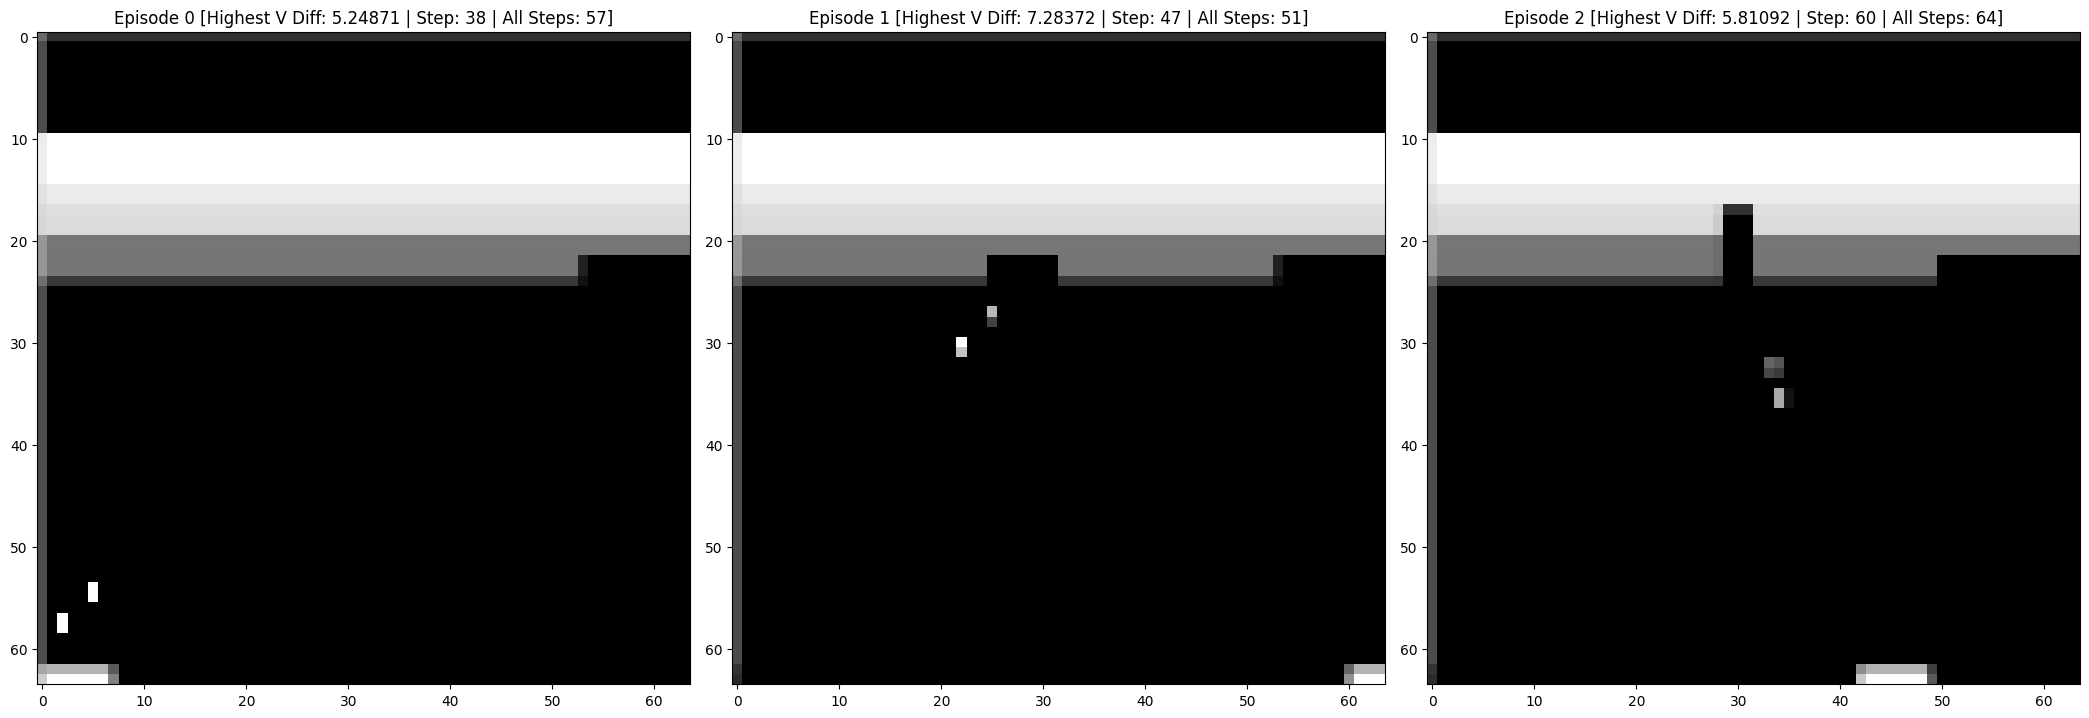

In [115]:
_, axs = plt.subplots(1, NUM_EPISODES, figsize=[NUM_EPISODES * 7, 15])

for i, ax in enumerate(axs):
    abs_diff = np.abs(records[i]['v_mc'] - records[i]['v_agent'])
    ind_max = abs_diff.argmax()
    diff = abs_diff[ind_max]
    img = img_by_obs(records[i]['states'][ind_max][0:1], state_shape)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Episode {i} [Highest V Diff: {diff:.5f} | Step: {ind_max} | All Steps: {records[i]['v_mc'].shape[0]}]")

plt.tight_layout()
plt.show()

High values signal that the performance of the agent (their skill and actuality of perception) is low, this is typically happening near the end of the game, where their knowledge of the environment is worse than ever.

# Bonus area
# Apply modifications to DQN

For inspiration see [Rainbow](https://arxiv.org/abs/1710.02298) - a version of q-learning that combines lots of them.

* [Quantile Regression DQN](https://arxiv.org/abs/1710.10044) (1.5 pt)
* [Prioritized Experience Replay](https://arxiv.org/abs/1710.10044) (2 pt)
* [n-step target without off-policy correction](https://arxiv.org/abs/1901.07510) (1 pt)
* [Clipped Double DQN](https://arxiv.org/abs/1802.09477v3) (0.5 pt)
* [Noisy networks](https://arxiv.org/abs/1706.10295) (1 pts)
* [DRQN](https://arxiv.org/abs/1507.06527) (3 pt)

In [ ]:
from collections import deque


class PrioritizedReplayBuffer:
    def __init__(self, size):
        """
        Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.

        Note: for this assignment you can pick any data structure you want.
              If you want to keep it simple, you can store a list of tuples of (s, a, r, s') in self._storage
              However you may find out there are faster and/or more memory-efficient ways to do so.
        """
        self._storage = deque(maxlen=size)

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        '''
        Make sure, _storage will not exceed _maxsize.
        Make sure, FIFO rule is being followed: the oldest examples has to be removed earlier
        '''
        data = (obs_t, action, reward, obs_tp1, done)
        self._storage.append(data)


    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an episode and 0 otherwise.
        """
        samples = [self._storage[i] for i in np.random.choice(len(self._storage), size=batch_size)]
            # randomly generate batch_size integers
            # to be used as indexes of samples


        states = np.array([sample[0] for sample in samples])
        actions = np.array([sample[1] for sample in samples])
        rewards = np.array([sample[2] for sample in samples])
        next_states = np.array([sample[3] for sample in samples])
        is_done = np.array([sample[4] for sample in samples])
            # collect <s,a,r,s',done> for each index

        return states, actions, rewards, next_states, is_done
            # <states>, <actions>, <rewards>, <next_states>, <is_done>